# Module 07 — Cell Type Annotation

This notebook visualizes cell type annotation results from
`scripts/07_annotation.py`. After integration (Module 05) and Leiden
clustering (Module 06), de novo annotation is performed using IVD-specific
marker gene signatures, with CellTypist validation for non-mesenchymal subtypes.

**Sections**
- §1–§5 — v5 atlas (CCA-flat, status: completed 2026-03-25)
- §6 — tiered v4 atlas (status: Module 07 complete 2026-05-15; pending human checkpoint)

**v5 cell-type counts:** NP 5 · AF 4 · CEP 7 · all_cells 16

**Tiered v4 cell-type counts (2026-05-15 reruns):** NP 8 · AF 7 · CEP 6 · all_cells 19

**Data sources**
- v5: `data/integrated/{NP,AF,CEP,all_cells}.h5ad` · `results/integration/`
- tiered v4: `data/integrated/tiered_v4/{NP,AF,CEP,all_cells}.h5ad` · `results/integration/tiered_v4/`


In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='scanpy')

from pathlib import Path

import anndata
anndata.settings.allow_write_nullable_strings = True

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from IPython.display import Image, display, Markdown

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path('..').resolve()
INT_DIR = BASE / 'data' / 'integrated'
RESULTS_DIR = BASE / 'results' / 'integration'
DOTPLOT_DIR = RESULTS_DIR / 'annotation_dotplots'
MARKER_DIR = RESULTS_DIR / 'cluster_markers'
CELLTYPIST_DIR = RESULTS_DIR / 'celltypist_validation'

COMPARTMENTS = {
    'NP': INT_DIR / 'NP.h5ad',
    'AF': INT_DIR / 'AF.h5ad',
    'CEP': INT_DIR / 'CEP.h5ad',
}

for name, path in COMPARTMENTS.items():
    print(f'  {name}: {"found" if path.exists() else "NOT FOUND"}')

  NP: found
  AF: found
  CEP: found


## §1 — Cell Type Definitions (v5)

The table below shows all annotated cell types with their defining markers,
cluster assignments, and confidence distributions.

In [2]:
# Load and display cell type definitions
ct_def_path = RESULTS_DIR / 'cell_type_definitions.tsv'
if ct_def_path.exists():
    ct_defs = pd.read_csv(ct_def_path, sep='\t')
    display(ct_defs.style.set_caption('Cell Type Definitions — All Compartments'))
else:
    print('Cell type definitions file not found')

,object,cell_type,coarse_cell_type,n_cells,clusters,canonical_markers,confidence_distribution
0,NP,Endothelial,Endothelial,2645,"NM0,NM1,NM4","PECAM1,VWF,CDH5",high=1381; medium=1264
1,NP,Macrophage_M2,Macrophage,181,NM3,"CD163,MRC1,MSR1,TGFB1",high=181; medium=0
2,NP,NP_fibrocartilaginous,Fibroblast_like,73764,"M2,M3,M4,M5","COL1A1,COL2A1,VCAN",high=73764; medium=0
3,NP,NP_mature_chondrocyte,Chondrocyte_like,185794,"M0,M1,M6","ACAN,COL2A1,SOX9,COMP,PRG4",high=185794; medium=0
4,NP,T_cell_CD8,T_cell,583,NM2,"CD8A,CD8B,GZMB,PRF1",medium=583; high=0
5,AF,AF_inner,Chondrocyte_like,32839,"M0,M8,M9","COL2A1,ACAN,SOX9",high=32839
6,AF,AF_outer,Fibroblast_like,51729,"M1,M2,M3,M4,M5,M6,M7","COL1A1,COL1A2,THY1,DCN,LUM",high=51729
7,AF,Endothelial,Endothelial,22,NM1,"PECAM1,VWF,CDH5",high=22
8,AF,Macrophage_M2,Macrophage,34,NM0,"CD163,MRC1,MSR1,TGFB1",high=34
9,CEP,EP_hyaline,Chondrocyte_like,12597,M1,"COL2A1,COL10A1,SOX9",high=12597; medium=0


## §2 — Annotated UMAPs per Compartment (v5)

UMAP colored by final `cell_type` annotation for each compartment.

### NP — Annotated UMAP

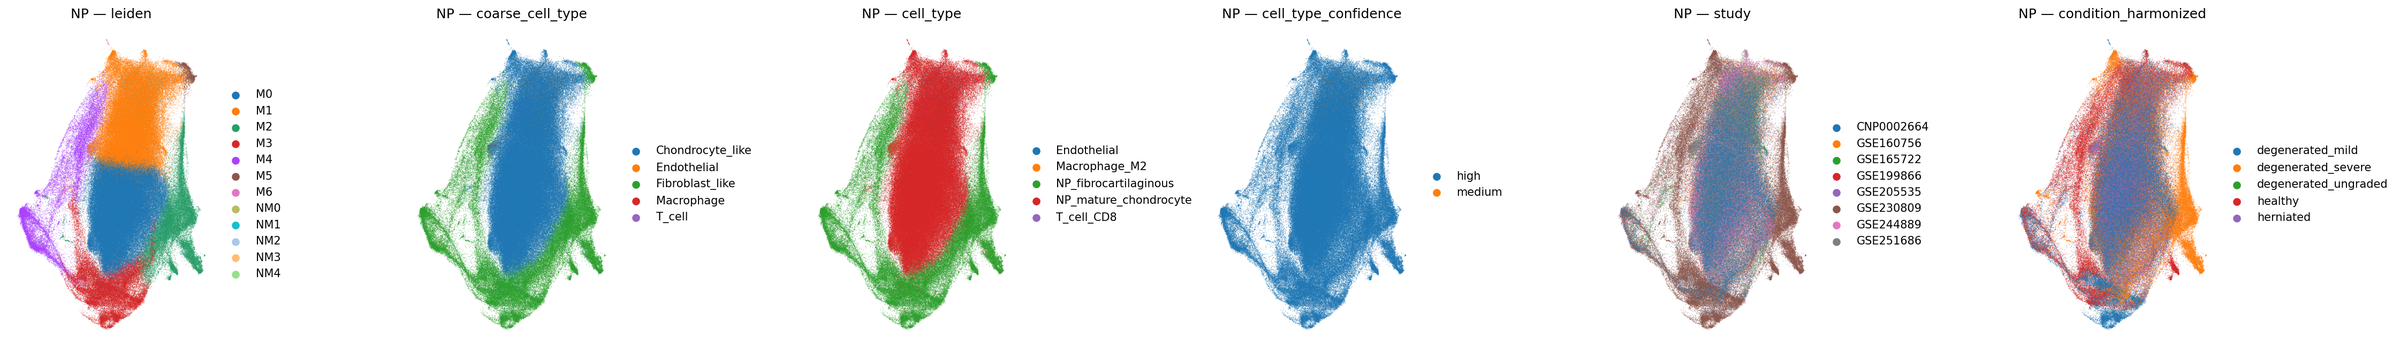

### AF — Annotated UMAP

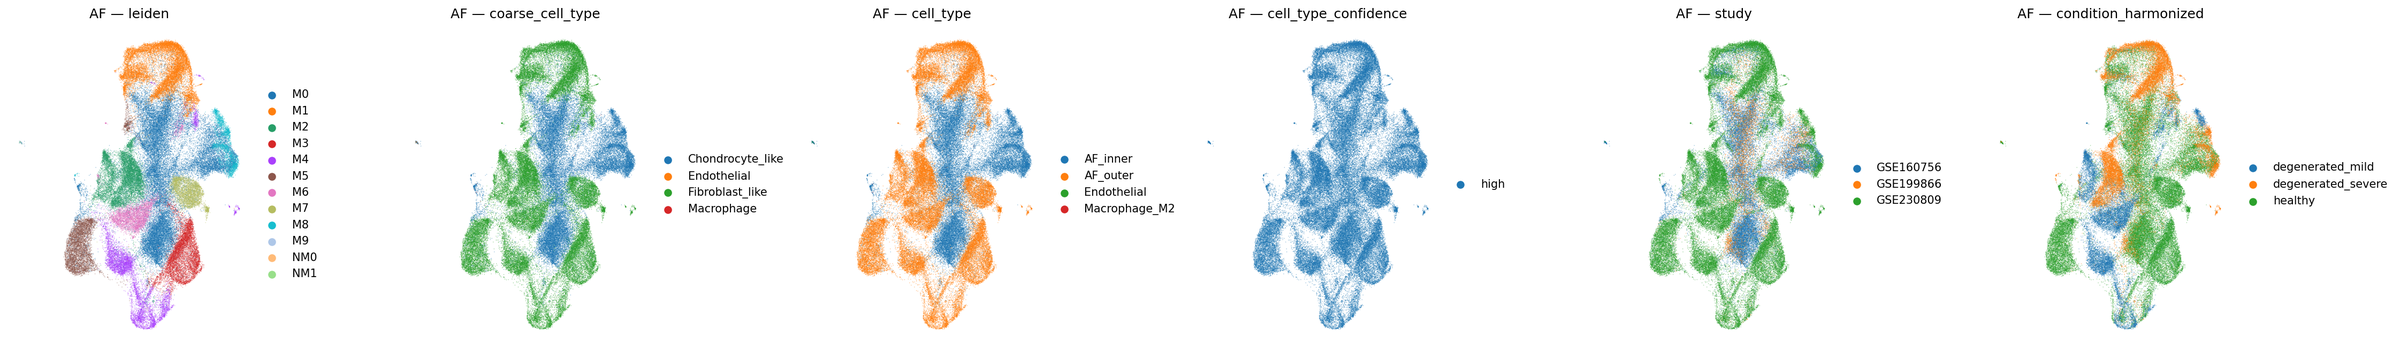

### CEP — Annotated UMAP

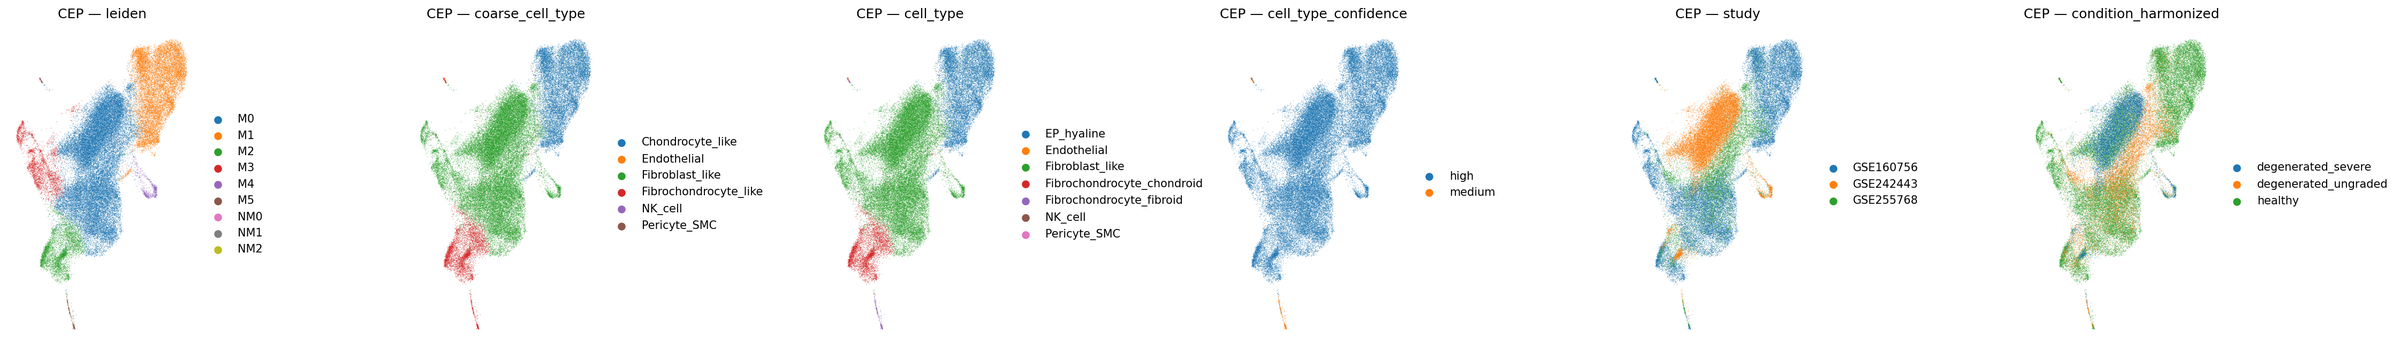

### all_cells — Annotated UMAP

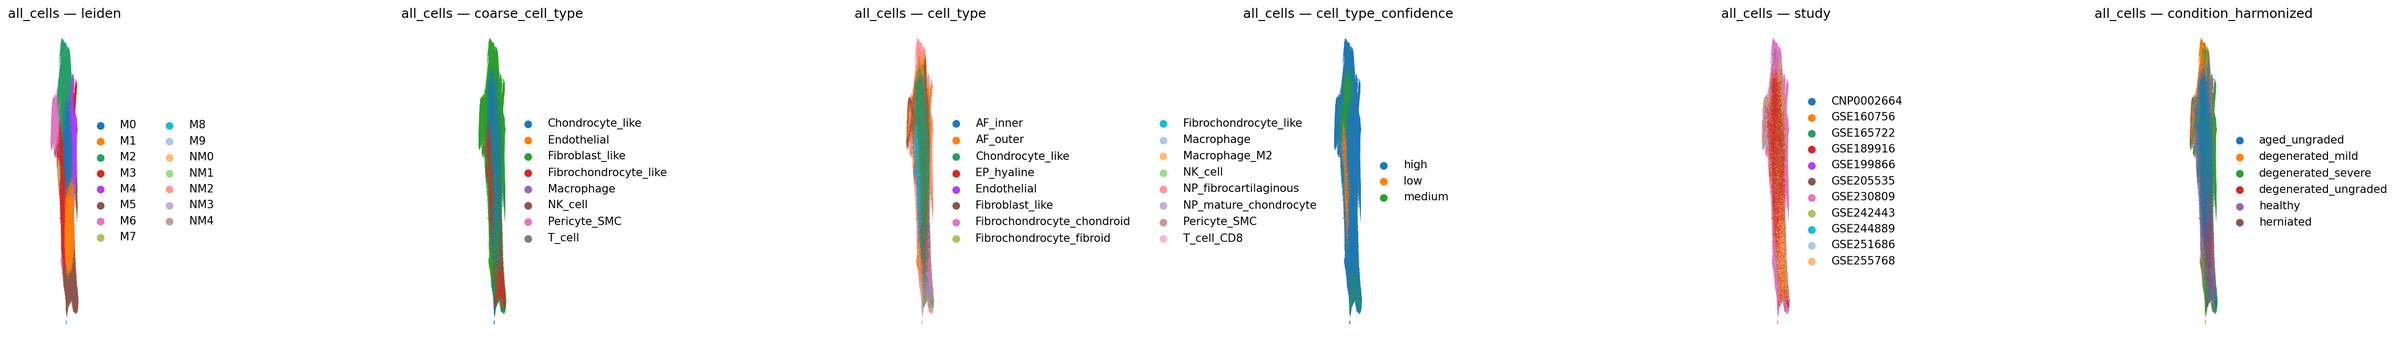

In [3]:
# Display pre-generated annotated UMAP images
for comp in ['NP', 'AF', 'CEP', 'all_cells']:
    umap_path = RESULTS_DIR / f'umap_{comp}_annotated.png'
    if umap_path.exists():
        display(Markdown(f'### {comp} — Annotated UMAP'))
        display(Image(filename=str(umap_path), width=1500))
    else:
        # Fallback: basic UMAP plot
        umap_basic = RESULTS_DIR / f'umap_{comp}.png'
        if umap_basic.exists():
            display(Markdown(f'### {comp} — UMAP'))
            display(Image(filename=str(umap_basic), width=1500))
        else:
            print(f'No UMAP image for {comp}')

## §3 — Marker Expression Dot Plots (v5)

Dot plots show expression of canonical markers per cell type. Dot size
represents fraction of cells expressing the gene; color intensity represents
mean expression level.

Annotation dot plots: 9 PDF files
  AF_all_markers_canonical_markers.pdf
  AF_mesenchymal_coarse_canonical_markers.pdf
  AF_non_mesenchymal_coarse_canonical_markers.pdf
  CEP_all_markers_canonical_markers.pdf
  CEP_mesenchymal_coarse_canonical_markers.pdf
  CEP_non_mesenchymal_coarse_canonical_markers.pdf
  NP_all_markers_canonical_markers.pdf
  NP_mesenchymal_coarse_canonical_markers.pdf
  NP_non_mesenchymal_coarse_canonical_markers.pdf

Generating marker dot plots from integrated objects...


### NP — Canonical Marker Expression

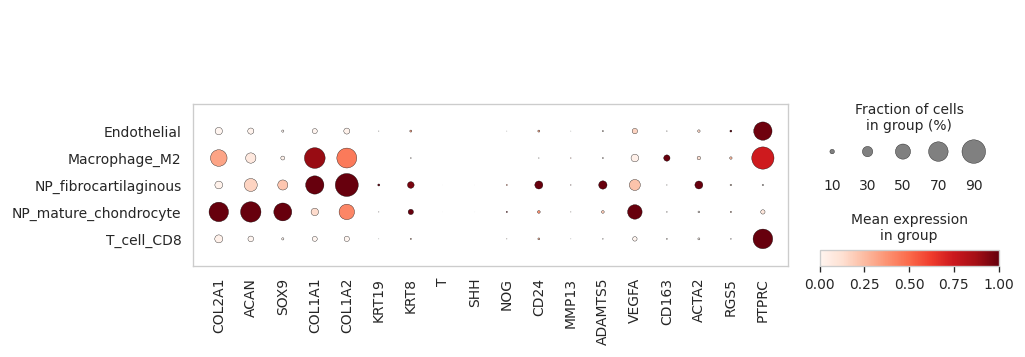

### AF — Canonical Marker Expression

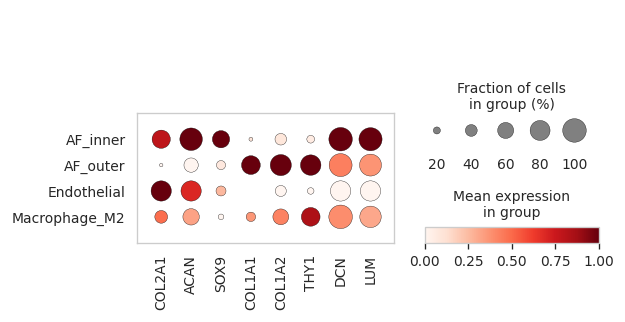

### CEP — Canonical Marker Expression

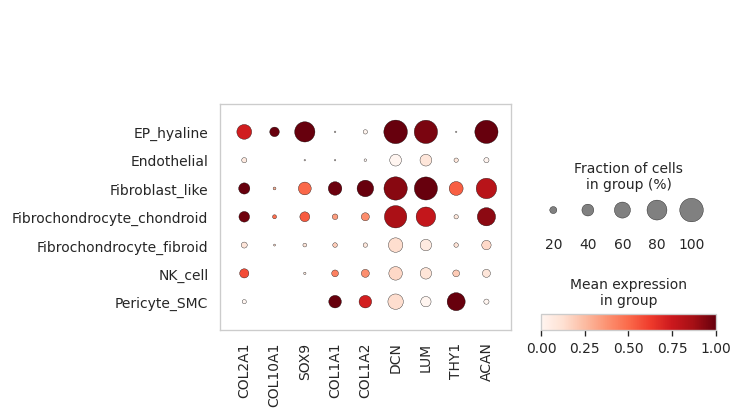

In [4]:
# List available annotation dot plots
dotplot_files = sorted(DOTPLOT_DIR.glob('*.pdf'))
print(f'Annotation dot plots: {len(dotplot_files)} PDF files')
for f in dotplot_files:
    print(f'  {f.name}')

# Note: PDF dot plots cannot be embedded directly in notebooks.
# They are available in results/integration/annotation_dotplots/ for review.
# Instead, show marker expression from the integrated objects directly.

print('\nGenerating marker dot plots from integrated objects...')

MARKERS_PER_COMP = {
    'NP': ['COL2A1', 'ACAN', 'SOX9', 'COL1A1', 'COL1A2', 'KRT19', 'KRT8',
           'T', 'SHH', 'NOG', 'CD24', 'MMP13', 'ADAMTS5', 'VEGFA',
           'CD163', 'ACTA2', 'RGS5', 'PTPRC'],
    'AF': ['COL2A1', 'ACAN', 'SOX9', 'COL1A1', 'COL1A2', 'THY1', 'DCN', 'LUM'],
    'CEP': ['COL2A1', 'COL10A1', 'SOX9', 'COL1A1', 'COL1A2', 'DCN', 'LUM', 'THY1', 'ACAN'],
}

for comp_name, comp_path in COMPARTMENTS.items():
    if not comp_path.exists():
        continue
    markers = MARKERS_PER_COMP.get(comp_name, [])
    if not markers:
        continue

    adata = sc.read_h5ad(comp_path)
    if 'cell_type' not in adata.obs.columns:
        del adata
        continue

    available = [g for g in markers if g in adata.var_names]
    if not available:
        del adata
        continue

    display(Markdown(f'### {comp_name} — Canonical Marker Expression'))
    sc.pl.dotplot(adata, var_names=available, groupby='cell_type',
                  standard_scale='var', show=True)
    del adata

## §4 — Annotation Confidence (v5)

Distribution of annotation confidence levels (high/medium/low) across cell
types, showing how confidently each cell type was assigned.

In [5]:
# Load annotation confidence from integrated objects
for comp_name, comp_path in COMPARTMENTS.items():
    if not comp_path.exists():
        continue
    adata = sc.read_h5ad(comp_path, backed='r')
    obs_df = adata.obs.to_memory() if hasattr(adata.obs, 'to_memory') else adata.obs.copy()
    adata.file.close()

    if 'cell_type' not in obs_df.columns:
        continue

    display(Markdown(f'### {comp_name} — Cell Type Summary'))

    # Cell type counts
    ct_counts = obs_df['cell_type'].value_counts()
    print(f'{comp_name}: {len(obs_df):,} cells, {ct_counts.shape[0]} cell types')
    print(ct_counts.to_string())
    print()

    # Confidence distribution if available
    if 'cell_type_confidence' in obs_df.columns:
        conf_ct = pd.crosstab(obs_df['cell_type'], obs_df['cell_type_confidence'])
        display(conf_ct.style.set_caption(f'{comp_name} — Confidence per Cell Type'))

    del obs_df

### NP — Cell Type Summary

NP: 262,967 cells, 5 cell types
cell_type
NP_mature_chondrocyte    185794
NP_fibrocartilaginous     73764
Endothelial                2645
T_cell_CD8                  583
Macrophage_M2               181



cell_type_confidence,high,medium
cell_type,,
Endothelial,1381,1264
Macrophage_M2,181,0
NP_fibrocartilaginous,73764,0
NP_mature_chondrocyte,185794,0
T_cell_CD8,0,583


### AF — Cell Type Summary

AF: 84,624 cells, 4 cell types
cell_type
AF_outer         51729
AF_inner         32839
Macrophage_M2       34
Endothelial         22



cell_type_confidence,high
cell_type,
AF_inner,32839
AF_outer,51729
Endothelial,22
Macrophage_M2,34


### CEP — Cell Type Summary

CEP: 50,858 cells, 7 cell types
cell_type
Fibroblast_like               33582
EP_hyaline                    12597
Fibrochondrocyte_chondroid     4292
Fibrochondrocyte_fibroid        298
Endothelial                      38
Pericyte_SMC                     30
NK_cell                          21



cell_type_confidence,high,medium
cell_type,,
EP_hyaline,12597,0
Endothelial,38,0
Fibroblast_like,33582,0
Fibrochondrocyte_chondroid,4292,0
Fibrochondrocyte_fibroid,0,298
NK_cell,21,0
Pericyte_SMC,30,0


## §5 — CellTypist Validation (v5)

CellTypist concordance tables comparing de novo annotations with automated
predictions for non-mesenchymal cell types.

In [6]:
# Load CellTypist concordance tables
concordance_files = sorted(CELLTYPIST_DIR.glob('*_concordance.tsv'))

if concordance_files:
    for f in concordance_files:
        comp = f.stem.replace('_concordance', '')
        df = pd.read_csv(f, sep='\t')
        display(Markdown(f'### {comp} CellTypist Concordance'))
        display(df)

        # Summary: fraction concordant
        n_concordant = df['concordant'].sum() if 'concordant' in df.columns else 0
        n_total = len(df)
        print(f'  Concordant clusters: {n_concordant}/{n_total} '
              f'({n_concordant/n_total*100:.0f}%)')
else:
    print('No CellTypist concordance files found')

### AF CellTypist Concordance

,cluster,n_cells,de_novo_label,celltypist_majority,celltypist_agreement_pct,concordant
0,0,34,Macrophage_M2,Fibroblasts,38.2,False
1,1,22,Endothelial,Endothelial cells,95.5,True


  Concordant clusters: 1/2 (50%)


### CEP CellTypist Concordance

,cluster,n_cells,de_novo_label,celltypist_majority,celltypist_agreement_pct,concordant
0,0,38,Endothelial,Endothelial cells,100.0,True
1,1,30,Pericyte_SMC,NK cells,76.7,False
2,2,21,NK_cell,Classical monocytes,52.4,False


  Concordant clusters: 1/3 (33%)


### NP CellTypist Concordance

,cluster,n_cells,de_novo_label,celltypist_majority,celltypist_agreement_pct,concordant
0,0,1277,Endothelial,Endothelial cells,43.8,True
1,1,1264,Endothelial,Classical monocytes,67.9,False
2,2,583,T_cell_CD8,Classical monocytes,46.3,False
3,3,181,Macrophage_M2,Macrophages,72.4,True
4,4,104,Endothelial,Endothelial cells,65.4,True


  Concordant clusters: 3/5 (60%)


## Status — v5 complete (2026-03-25)

### Summary
- De novo cell type annotation using IVD-specific marker gene signatures
- CellTypist validation for non-mesenchymal subtypes (Immune_All_Low model)
- NP: 5 cell types, AF: 4 cell types, CEP: 7 cell types
- Annotation confidence tracked via `cell_type_confidence` column
- Results stored in `cell_type` column of integrated objects

### Next steps
- Module 08: Pseudobulk differential expression analysis (healthy vs degenerated)
- Module 09: Biological interpretation (pathway enrichment, TF activity)
- Module 10: Trajectory/pseudotime analysis
- Module 11: Cell-cell communication

## §6 — Tiered v4 Atlas (2026-05-15)

Annotation results from the tiered v4 pipeline. The script `scripts/07_annotation.py`
was re-run on 2026-05-15 against `data/integrated/tiered_v4/` (commit `2d183ed`
added `--input-dir` / `--output-dir` flags so this run does not overwrite v5).

Run: 2026-05-15 18:54 → 19:45 (~51 min). Validator overall status: **PASSED**.

**Data sources**
- `data/integrated/tiered_v4/{NP,AF,CEP,all_cells}.h5ad` — annotated objects
- `results/integration/tiered_v4/cell_type_definitions.tsv` — cell type marker definitions
- `results/integration/tiered_v4/umap_{NP,AF,CEP,all_cells}_annotated.png`
- `results/integration/tiered_v4/cluster_markers/` — per-tier and within-coarse marker tables
- `results/integration/tiered_v4/annotation_dotplots/` — marker dot plots


In [7]:
# ── tiered_v4 paths ────────────────────────────────────────────────────────
TV4_INT_DIR = BASE / 'data' / 'integrated' / 'tiered_v4'
TV4_RESULTS_DIR = BASE / 'results' / 'integration' / 'tiered_v4'
TV4_DOTPLOT_DIR = TV4_RESULTS_DIR / 'annotation_dotplots'
TV4_MARKER_DIR = TV4_RESULTS_DIR / 'cluster_markers'
TV4_CELLTYPIST_DIR = TV4_RESULTS_DIR / 'celltypist_validation'

TV4_COMPARTMENTS = {
    'NP':  TV4_INT_DIR / 'NP.h5ad',
    'AF':  TV4_INT_DIR / 'AF.h5ad',
    'CEP': TV4_INT_DIR / 'CEP.h5ad',
    'all_cells': TV4_INT_DIR / 'all_cells.h5ad',
}

for name, path in TV4_COMPARTMENTS.items():
    print(f'  {name}: {"found" if path.exists() else "NOT FOUND"}')


  NP: found
  AF: found
  CEP: found
  all_cells: found


### §6a — Cell Type Definitions (tiered v4)

40 rows across the four objects (NP 8, AF 7, CEP 6, all_cells 19 cell types).
Each row lists the cell type, its coarse parent, the contributing cluster IDs,
the canonical markers used to call it, and the confidence breakdown.


In [8]:
tv4_ct_def_path = TV4_RESULTS_DIR / 'cell_type_definitions.tsv'
if tv4_ct_def_path.exists():
    tv4_ct_defs = pd.read_csv(tv4_ct_def_path, sep='\t')
    display(tv4_ct_defs.style.set_caption('Tiered v4 — Cell Type Definitions (all compartments)'))
else:
    print('tiered_v4 cell type definitions file not found')


,object,cell_type,coarse_cell_type,n_cells,clusters,canonical_markers,confidence_distribution
0,NP,Endothelial,Endothelial,1024,NM1,"PECAM1,VWF,CDH5",high=1024; low=0; medium=0
1,NP,Fibrochondrocyte_chondroid,Fibrochondrocyte_like,35078,"M14,M16,M7,M9","COL2A1,ACAN,SOX9",high=28725; medium=6353; low=0
2,NP,Macrophage_M2,Macrophage,47,NM4,"CD163,MRC1,MSR1,TGFB1",high=47; low=0; medium=0
3,NP,NK_cell,NK_cell,633,NM2,"NKG7,GNLY",high=633; low=0; medium=0
4,NP,NP_fibrocartilaginous,Fibroblast_like,105094,"M0,M11,M12,M17,M2,M20,M26,M3","COL1A1,COL2A1,VCAN",high=105094; low=0; medium=0
5,NP,NP_mature_chondrocyte,Chondrocyte_like,88364,"M1,M10,M13,M24,M4,M5,M6","ACAN,COL2A1,SOX9,COMP,PRG4",high=88364; low=0; medium=0
6,NP,Pericyte_SMC,Pericyte_SMC,90,NM3,"ACTA2,RGS5,PDGFRB",high=90; low=0; medium=0
7,NP,unassigned,unassigned,32621,"NM0,M15,M18,M19,M21,M22,M23,M25,M8",nan,low=32621; high=0; medium=0
8,AF,AF_inner,Chondrocyte_like,20999,"M10,M2,M3","COL2A1,ACAN,SOX9",high=20999; low=0; medium=0
9,AF,AF_outer,Fibroblast_like,58369,"M0,M1,M11,M12,M4,M5,M6,M7,M9","COL1A1,COL1A2,THY1,DCN,LUM",high=44414; medium=13955; low=0


### §6b — Annotated UMAPs per Compartment (tiered v4)

UMAP colored by final `cell_type` annotation for each compartment, including
the `all_cells` object which carries annotations transferred from the
compartment-specific objects (398,359 transferred + 44,905 de novo).


#### NP — Annotated UMAP (tiered v4)

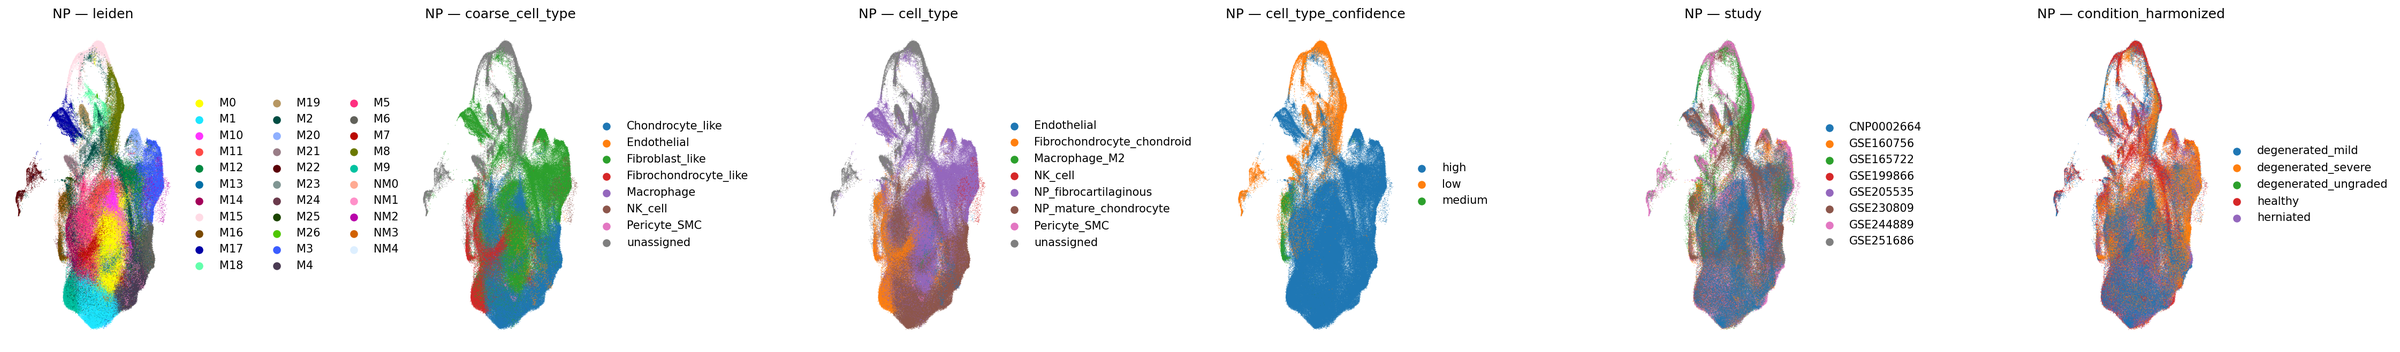

#### AF — Annotated UMAP (tiered v4)

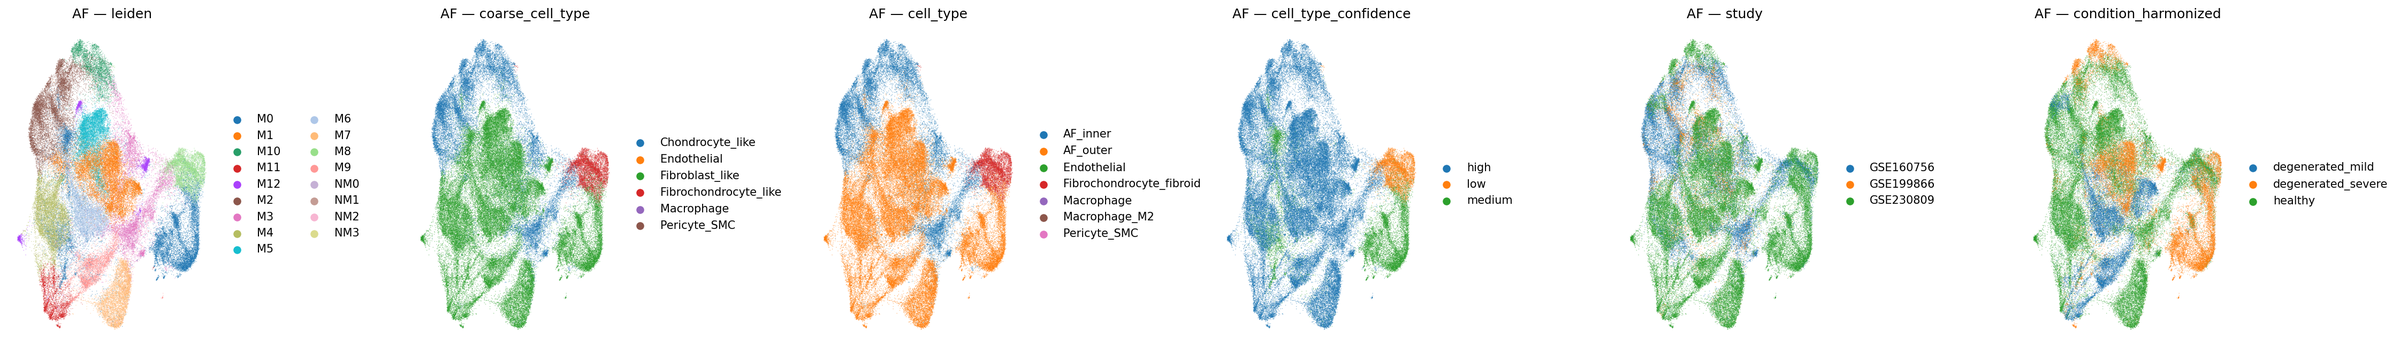

#### CEP — Annotated UMAP (tiered v4)

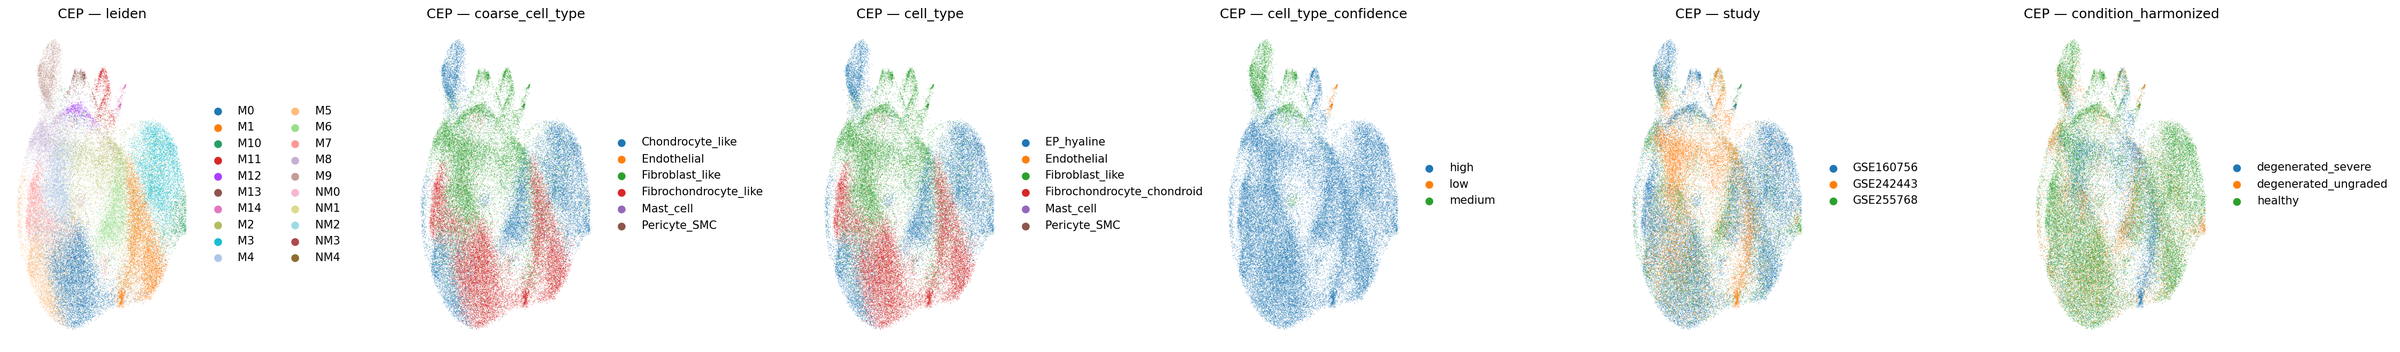

#### all_cells — Annotated UMAP (tiered v4)

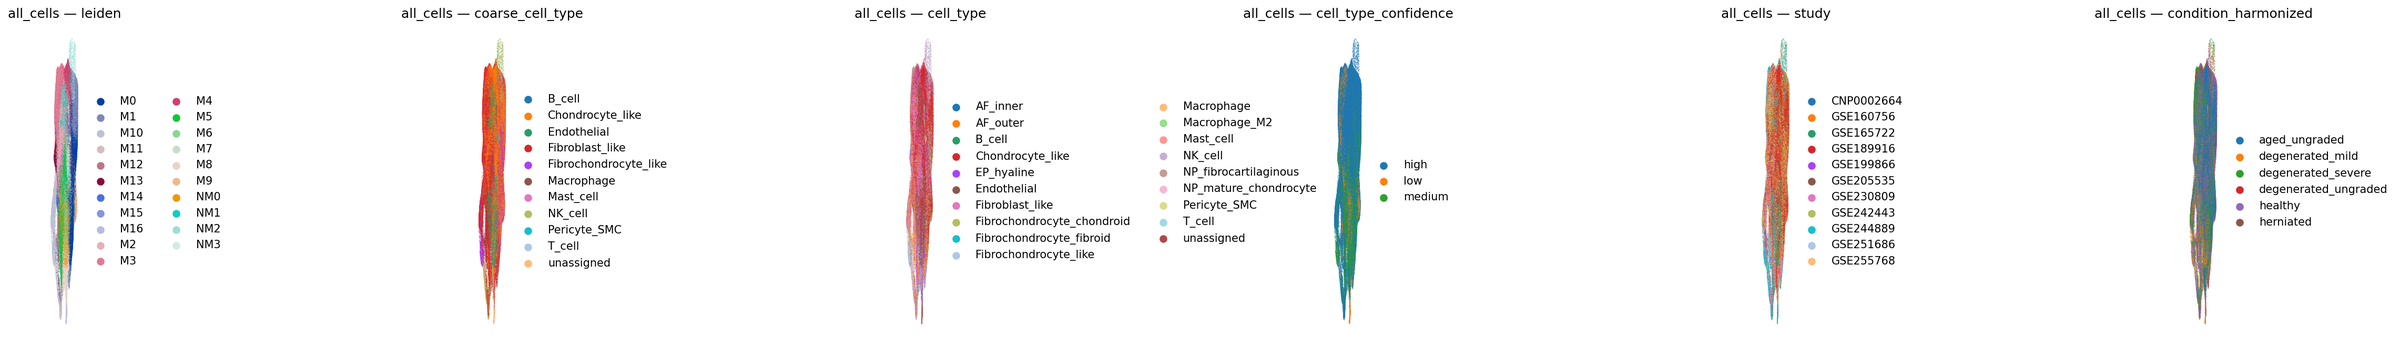

In [9]:
for comp in ['NP', 'AF', 'CEP', 'all_cells']:
    umap_path = TV4_RESULTS_DIR / f'umap_{comp}_annotated.png'
    if umap_path.exists():
        display(Markdown(f'#### {comp} — Annotated UMAP (tiered v4)'))
        display(Image(filename=str(umap_path), width=1500))
    else:
        print(f'No tiered_v4 UMAP image for {comp}')


### §6c — Cell-Type Counts and Confidence (tiered v4)

Per-compartment cell-type tally and confidence distribution. NP has 12.4%
`unassigned` cells (32,621/262,951) — soft warning flagged by the validator.


In [10]:
for comp_name, comp_path in TV4_COMPARTMENTS.items():
    if not comp_path.exists():
        continue
    adata = sc.read_h5ad(comp_path, backed='r')
    obs_df = adata.obs.to_memory() if hasattr(adata.obs, 'to_memory') else adata.obs.copy()
    adata.file.close()

    if 'cell_type' not in obs_df.columns:
        continue

    display(Markdown(f'#### {comp_name} — Cell Type Summary (tiered v4)'))

    ct_counts = obs_df['cell_type'].value_counts()
    print(f'{comp_name}: {len(obs_df):,} cells, {ct_counts.shape[0]} cell types')
    print(ct_counts.to_string())
    print()

    if 'cell_type_confidence' in obs_df.columns:
        conf_ct = pd.crosstab(obs_df['cell_type'], obs_df['cell_type_confidence'])
        display(conf_ct.style.set_caption(f'{comp_name} — Confidence per Cell Type (tiered v4)'))

    del obs_df


#### NP — Cell Type Summary (tiered v4)

NP: 262,951 cells, 8 cell types
cell_type
NP_fibrocartilaginous         105094
NP_mature_chondrocyte          88364
Fibrochondrocyte_chondroid     35078
unassigned                     32621
Endothelial                     1024
NK_cell                          633
Pericyte_SMC                      90
Macrophage_M2                     47



cell_type_confidence,high,low,medium
cell_type,,,
Endothelial,1024,0,0
Fibrochondrocyte_chondroid,28725,0,6353
Macrophage_M2,47,0,0
NK_cell,633,0,0
NP_fibrocartilaginous,105094,0,0
NP_mature_chondrocyte,88364,0,0
Pericyte_SMC,90,0,0
unassigned,0,32621,0


#### AF — Cell Type Summary (tiered v4)

AF: 84,624 cells, 7 cell types
cell_type
AF_outer                    58369
AF_inner                    20999
Fibrochondrocyte_fibroid     5200
Endothelial                    28
Macrophage                     13
Macrophage_M2                   8
Pericyte_SMC                    7



...

CEP: 50,840 cells, 6 cell types
cell_type
Fibrochondrocyte_chondroid    18224
EP_hyaline                    16363
Fibroblast_like               16182
Endothelial                      43
Pericyte_SMC                     15
Mast_cell                        13



cell_type_confidence,high,low,medium
cell_type,,,
EP_hyaline,13943,0,2420
Endothelial,37,6,0
Fibroblast_like,14575,221,1386
Fibrochondrocyte_chondroid,18224,0,0
Mast_cell,13,0,0
Pericyte_SMC,15,0,0


#### all_cells — Cell Type Summary (tiered v4)

all_cells: 410,643 cells, 19 cell types
cell_type
NP_fibrocartilaginous         105094
NP_mature_chondrocyte          88364
AF_outer                       58369
Fibrochondrocyte_chondroid     53302
Fibroblast_like                28467
AF_inner                       20999
EP_hyaline                     16363
Chondrocyte_like               11990
NK_cell                         8058
Endothelial                     5234
Fibrochondrocyte_fibroid        5200
Macrophage                      4618
T_cell                          1854
Fibrochondrocyte_like           1649
unassigned                       908
Pericyte_SMC                     105
Macrophage_M2                     47
Mast_cell                         13
B_cell                             9



cell_type_confidence,high,low,medium
cell_type,,,
AF_inner,20999,0,0
AF_outer,44414,0,13955
B_cell,9,0,0
Chondrocyte_like,6717,2700,2573
EP_hyaline,13943,0,2420
Endothelial,3812,6,1416
Fibroblast_like,14575,221,13671
Fibrochondrocyte_chondroid,46949,0,6353
Fibrochondrocyte_fibroid,0,5200,0


### §6d — Canonical Marker Expression (tiered v4)

Dot plots of canonical IVD markers grouped by `cell_type` for each
compartment-specific object. PDF versions live in
`results/integration/tiered_v4/annotation_dotplots/`.


#### NP — Canonical Marker Expression (tiered v4)

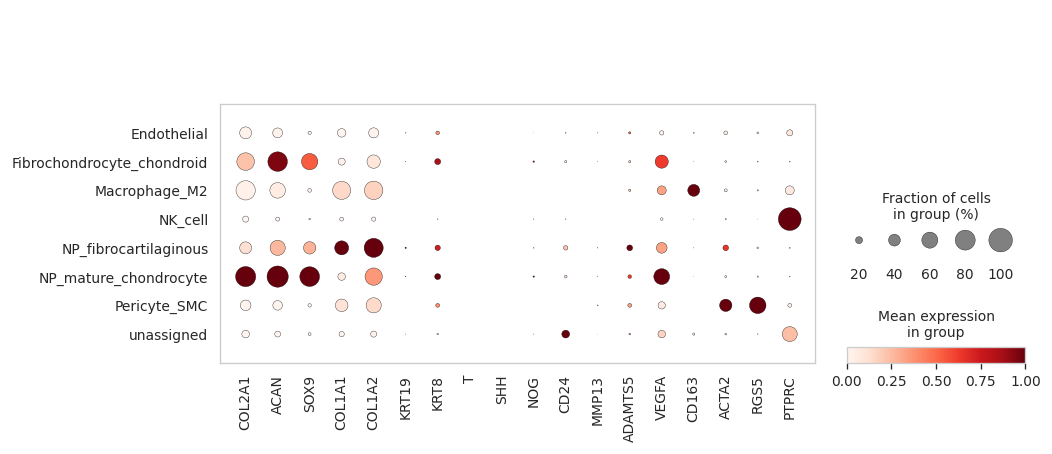

#### AF — Canonical Marker Expression (tiered v4)

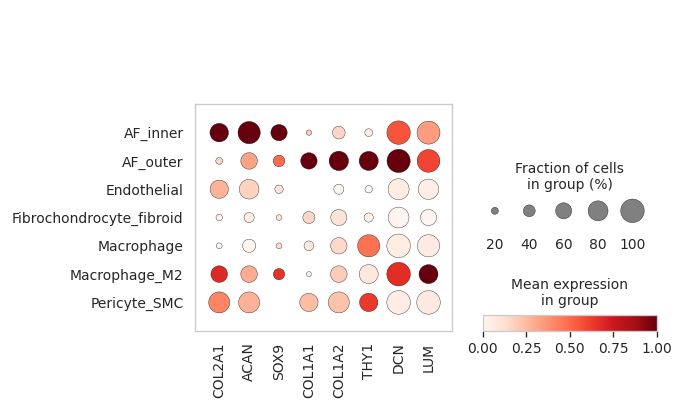

#### CEP — Canonical Marker Expression (tiered v4)

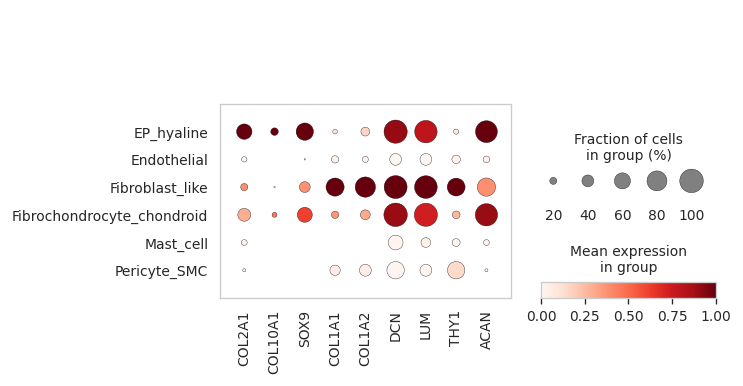

In [11]:
TV4_MARKERS_PER_COMP = {
    'NP': ['COL2A1', 'ACAN', 'SOX9', 'COL1A1', 'COL1A2', 'KRT19', 'KRT8',
           'T', 'SHH', 'NOG', 'CD24', 'MMP13', 'ADAMTS5', 'VEGFA',
           'CD163', 'ACTA2', 'RGS5', 'PTPRC'],
    'AF':  ['COL2A1', 'ACAN', 'SOX9', 'COL1A1', 'COL1A2', 'THY1', 'DCN', 'LUM'],
    'CEP': ['COL2A1', 'COL10A1', 'SOX9', 'COL1A1', 'COL1A2', 'DCN', 'LUM', 'THY1', 'ACAN'],
}

for comp_name in ['NP', 'AF', 'CEP']:
    comp_path = TV4_COMPARTMENTS[comp_name]
    if not comp_path.exists():
        continue
    markers = TV4_MARKERS_PER_COMP.get(comp_name, [])
    if not markers:
        continue

    adata = sc.read_h5ad(comp_path)
    if 'cell_type' not in adata.obs.columns:
        del adata
        continue

    available = [g for g in markers if g in adata.var_names]
    if not available:
        del adata
        continue

    display(Markdown(f'#### {comp_name} — Canonical Marker Expression (tiered v4)'))
    sc.pl.dotplot(adata, var_names=available, groupby='cell_type',
                  standard_scale='var', show=True)
    del adata


### §6e — Per-Tier Marker Tables (tiered v4)

The tiered v4 annotator emits two flavors of marker table:
- `*_<tier>_markers.tsv` — markers separating coarse types within a compartment×tier.
- `*_<tier>_<CoarseType>_within_markers.tsv` — markers separating fine types
  within a single coarse group (stage-2 annotation, only present where the coarse
  group contains multiple fine types).


In [12]:
tv4_marker_files = sorted(TV4_MARKER_DIR.glob('*.tsv'))
print(f'Tiered v4 marker tables: {len(tv4_marker_files)} files\n')
for f in tv4_marker_files:
    print(f'  {f.name}')


Tiered v4 marker tables: 14 files

  AF_mesenchymal_Chondrocyte_like_within_markers.tsv
  AF_mesenchymal_Fibroblast_like_within_markers.tsv
  AF_mesenchymal_markers.tsv
  AF_non_mesenchymal_Macrophage_within_markers.tsv
  AF_non_mesenchymal_markers.tsv
  CEP_mesenchymal_Chondrocyte_like_within_markers.tsv
  CEP_mesenchymal_Fibrochondrocyte_like_within_markers.tsv
  CEP_mesenchymal_markers.tsv
  CEP_non_mesenchymal_markers.tsv
  NP_mesenchymal_Chondrocyte_like_within_markers.tsv
  NP_mesenchymal_Fibroblast_like_within_markers.tsv
  NP_mesenchymal_Fibrochondrocyte_like_within_markers.tsv
  NP_mesenchymal_markers.tsv
  NP_non_mesenchymal_markers.tsv


### §6f — Validator Warnings (tiered v4)

The 2026-05-15 run finished `Overall: PASSED` but raised three soft warnings
that the human checkpoint should weigh in on:

1. **NP `unassigned` = 12.4%** (32,621 cells) — above the 10% spec threshold.
   These are mesenchymal clusters that did not score above the stage-1
   coarse-marker cutoff for any of Chondrocyte_like / Fibroblast_like /
   Fibrochondrocyte_like. Candidates to review: do they form a distinct
   trajectory midpoint, or are they low-quality clusters that should be
   merged into a neighbor?
2. **CellTypist validation failed on CEP non-mesenchymal cells** with
   `Invalid expression matrix in .X, expect log1p normalized expression to
   10000 counts per cell`. Coarse and fine labels were assigned by the
   marker-based annotator unaffected; only the automated secondary check
   is missing. Fix is one-line in `07_annotation.py` (normalize a copy
   of `.X` before handing to CellTypist).
3. **`all_cells`: no cluster marker tables found** — expected, because
   annotations on the `all_cells` object are transferred from the
   compartment-specific objects rather than recomputed. Validator does
   not currently know to skip this check for transfer-mode objects.


## Status — Module 07 tiered v4 complete (2026-05-15)

### Summary
- De novo cell type annotation via stage-1 coarse markers + stage-2 fine
  markers; CellTypist as secondary validator for non-mesenchymal subtypes.
- **NP 8 · AF 7 · CEP 6 · all_cells 19** cell types — finer partitions than
  v5 (NP 5 · AF 4 · CEP 7 · all_cells 16), consistent with the larger
  Module 06 tiered v4 cluster counts (NP 32, AF 17, CEP 20, all_cells 21).
- 19 supplementary marker tables in `cluster_markers/`; 9 dot plots in
  `annotation_dotplots/`.
- Run wall time ~51 min. Annotated h5ads at
  `data/integrated/tiered_v4/{NP,AF,CEP,all_cells}.h5ad`.

### Human checkpoint
- NP `unassigned` cohort (12.4%) — accept as biologically real, merge into a
  neighbor, or re-run with a relaxed stage-1 cutoff?
- CellTypist `.X` normalization fix — schedule before Module 08?
- Coarse-type naming: compartment-specific labels (`NP_fibrocartilaginous`,
  `NP_mature_chondrocyte`, `AF_outer`, `AF_inner`, `EP_hyaline`) coexist with
  generic labels (`Fibroblast_like`, `Chondrocyte_like`, `Fibrochondrocyte_like`)
  in the `all_cells` object — is this the intended cross-compartment naming
  scheme or should it be harmonized?

### Next steps (if checkpoint clears)
- Module 08: pseudobulk DE on tiered v4 cell types.
- Module 09–12 to follow on tiered v4 once Module 08 lands.
